# VitroVision — Growth Curve & Statistical Analysis
เปรียบเทียบการเจริญของ *Capsicum annuum* L. ใน 5 สูตร MS  
**CSBI analysis** — ใช้ข้อมูลจาก `vitroshelf.db` ที่ phenotyper.py บันทึกไว้

| สูตร | Treatment |
|------|-----------|
| A | MS (control) |
| B | MS + 1 mg/L BAP |
| C | MS + 5 mg/L BAP |
| D | MS + 5 mg/L BAP + 0.05 mg/L NAA |
| E | MS + 1 mg/L IBA |

In [1]:
import sys
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# path ไปยัง DB (relative จาก notebooks/)
DB_PATH = Path('..') / 'shelf_manager' / 'vitroshelf.db'
assert DB_PATH.exists(), f'ไม่พบ DB: {DB_PATH.resolve()}'

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('DB path:', DB_PATH.resolve())

DB path: C:\Users\User\OneDrive\Desktop\Projects\Other\VitroVision\shelf_manager\vitroshelf.db


## 1. โหลดข้อมูลจาก DB

In [2]:
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

df = pd.read_sql_query("""
    SELECT
        i.bottle_id,
        b.media_formula,
        b.pgr_detail,
        i.day_point,
        i.date_taken,
        i.status,
        i.green_coverage_pct,
        i.leaf_color_index,
        i.shoot_count_cv,
        i.texture_entropy,
        i.brown_coverage_pct,
        i.vigor_score,
        i.media_color_cv,
        i.phenotype_method
    FROM images i
    JOIN bottles b ON i.bottle_id = b.bottle_id
    WHERE i.green_coverage_pct IS NOT NULL
    ORDER BY b.media_formula, i.bottle_id, i.day_point
""", conn)
conn.close()

print(f'Total records: {len(df)}')
if df.empty:
    print('\n⚠️  ยังไม่มีข้อมูล phenotyping — เริ่มสแกนขวดก่อนแล้วค่อยรัน notebook ใหม่')
else:
    print(f'Bottles: {df.bottle_id.nunique()}')
    print(f'Day points: {sorted(df.day_point.unique())}')
df.head()

Total records: 0

⚠️  ยังไม่มีข้อมูล phenotyping — เริ่มสแกนขวดก่อนแล้วค่อยรัน notebook ใหม่


,bottle_id,media_formula,pgr_detail,day_point,date_taken,status,green_coverage_pct,leaf_color_index,shoot_count_cv,texture_entropy,brown_coverage_pct,vigor_score,media_color_cv,phenotype_method


In [3]:
if df.empty:
    print('DB ว่าง — ใช้ข้อมูลจำลองเพื่อทดสอบ notebook')
    rng = np.random.default_rng(42)
    rows = []
    # สูตรกับพฤติกรรมที่ต่างกัน (simulate จาก literature)
    formula_params = {
        'A': dict(green_base=12, green_growth=0.5, lci_base=1.3, lci_growth=0.02, brown=2.0, shoot=2),
        'B': dict(green_base=18, green_growth=0.9, lci_base=1.6, lci_growth=0.03, brown=1.5, shoot=4),
        'C': dict(green_base=22, green_growth=1.1, lci_base=1.8, lci_growth=0.04, brown=1.0, shoot=6),
        'D': dict(green_base=20, green_growth=1.0, lci_base=1.7, lci_growth=0.03, brown=1.2, shoot=5),
        'E': dict(green_base=14, green_growth=0.6, lci_base=1.4, lci_growth=0.02, brown=3.0, shoot=3),
    }
    bottle_ranges = {'A': (1,20), 'B': (21,40), 'C': (41,60), 'D': (61,80), 'E': (81,100)}

    for formula, p in formula_params.items():
        lo, hi = bottle_ranges[formula]
        for bottle_n in range(lo, hi + 1):
            bottle_id = f'S01-A{(bottle_n - 1) % 5 + 1:01d}-{bottle_n:02d}'
            for day in [0, 7, 14, 21, 28]:
                green = max(0, p['green_base'] + p['green_growth'] * day + rng.normal(0, 2))
                lci   = max(0.5, p['lci_base'] + p['lci_growth'] * day + rng.normal(0, 0.1))
                brown = max(0, p['brown'] + rng.normal(0, 0.5))
                entropy = round(rng.uniform(5.5, 7.5), 4)
                vigor = min(10, max(0, green/8 + (lci-1)/0.5 - brown/5))
                shoot = max(0, int(p['shoot'] + day * 0.1 + rng.normal(0, 1)))
                contaminated = brown > 4.5
                status = 'contaminated' if contaminated else 'healthy'
                rows.append({
                    'bottle_id': bottle_id,
                    'media_formula': formula,
                    'pgr_detail': '',
                    'day_point': day,
                    'date_taken': f'2026-06-{7 + day:02d}',
                    'status': status,
                    'green_coverage_pct': round(green, 2),
                    'leaf_color_index': round(lci, 4),
                    'shoot_count_cv': shoot,
                    'texture_entropy': entropy,
                    'brown_coverage_pct': round(brown, 2),
                    'vigor_score': round(vigor, 2),
                    'media_color_cv': 'normal' if day < 14 else ('yellow' if formula == 'E' else 'clear'),
                    'phenotype_method': 'mock_data',
                })
    df = pd.DataFrame(rows)
    print(f'Mock data: {len(df)} records, {df.bottle_id.nunique()} bottles')
else:
    print(f'Real data: {len(df)} records')

DB ว่าง — ใช้ข้อมูลจำลองเพื่อทดสอบ notebook
Mock data: 500 records, 100 bottles


In [4]:
# ถ้า media_formula ว่างให้ map จาก bottle_id range
# 001-020 = A, 021-040 = B, 041-060 = C, 061-080 = D, 081-100 = E
FORMULA_MAP = {
    'A': 'MS (control)',
    'B': 'MS + 1 BAP',
    'C': 'MS + 5 BAP',
    'D': 'MS + 5 BAP + 0.05 NAA',
    'E': 'MS + 1 IBA',
}

def infer_formula(bottle_id):
    try:
        n = int(bottle_id[-3:])
    except (ValueError, TypeError):
        return 'unknown'
    if n <= 20:  return 'A'
    if n <= 40:  return 'B'
    if n <= 60:  return 'C'
    if n <= 80:  return 'D'
    return 'E'

df['formula'] = df['media_formula'].where(
    df['media_formula'].notna() & (df['media_formula'] != ''),
    df['bottle_id'].apply(infer_formula)
)
df['formula_label'] = df['formula'].map(FORMULA_MAP).fillna(df['formula'])

print('Distribution per formula:')
df.groupby('formula_label')['bottle_id'].nunique()

Distribution per formula:


formula_label
MS (control)             20
MS + 1 BAP               20
MS + 1 IBA               20
MS + 5 BAP               20
MS + 5 BAP + 0.05 NAA    20
Name: bottle_id, dtype: int64

## 2. Growth Curves — mean ± SE per formulation

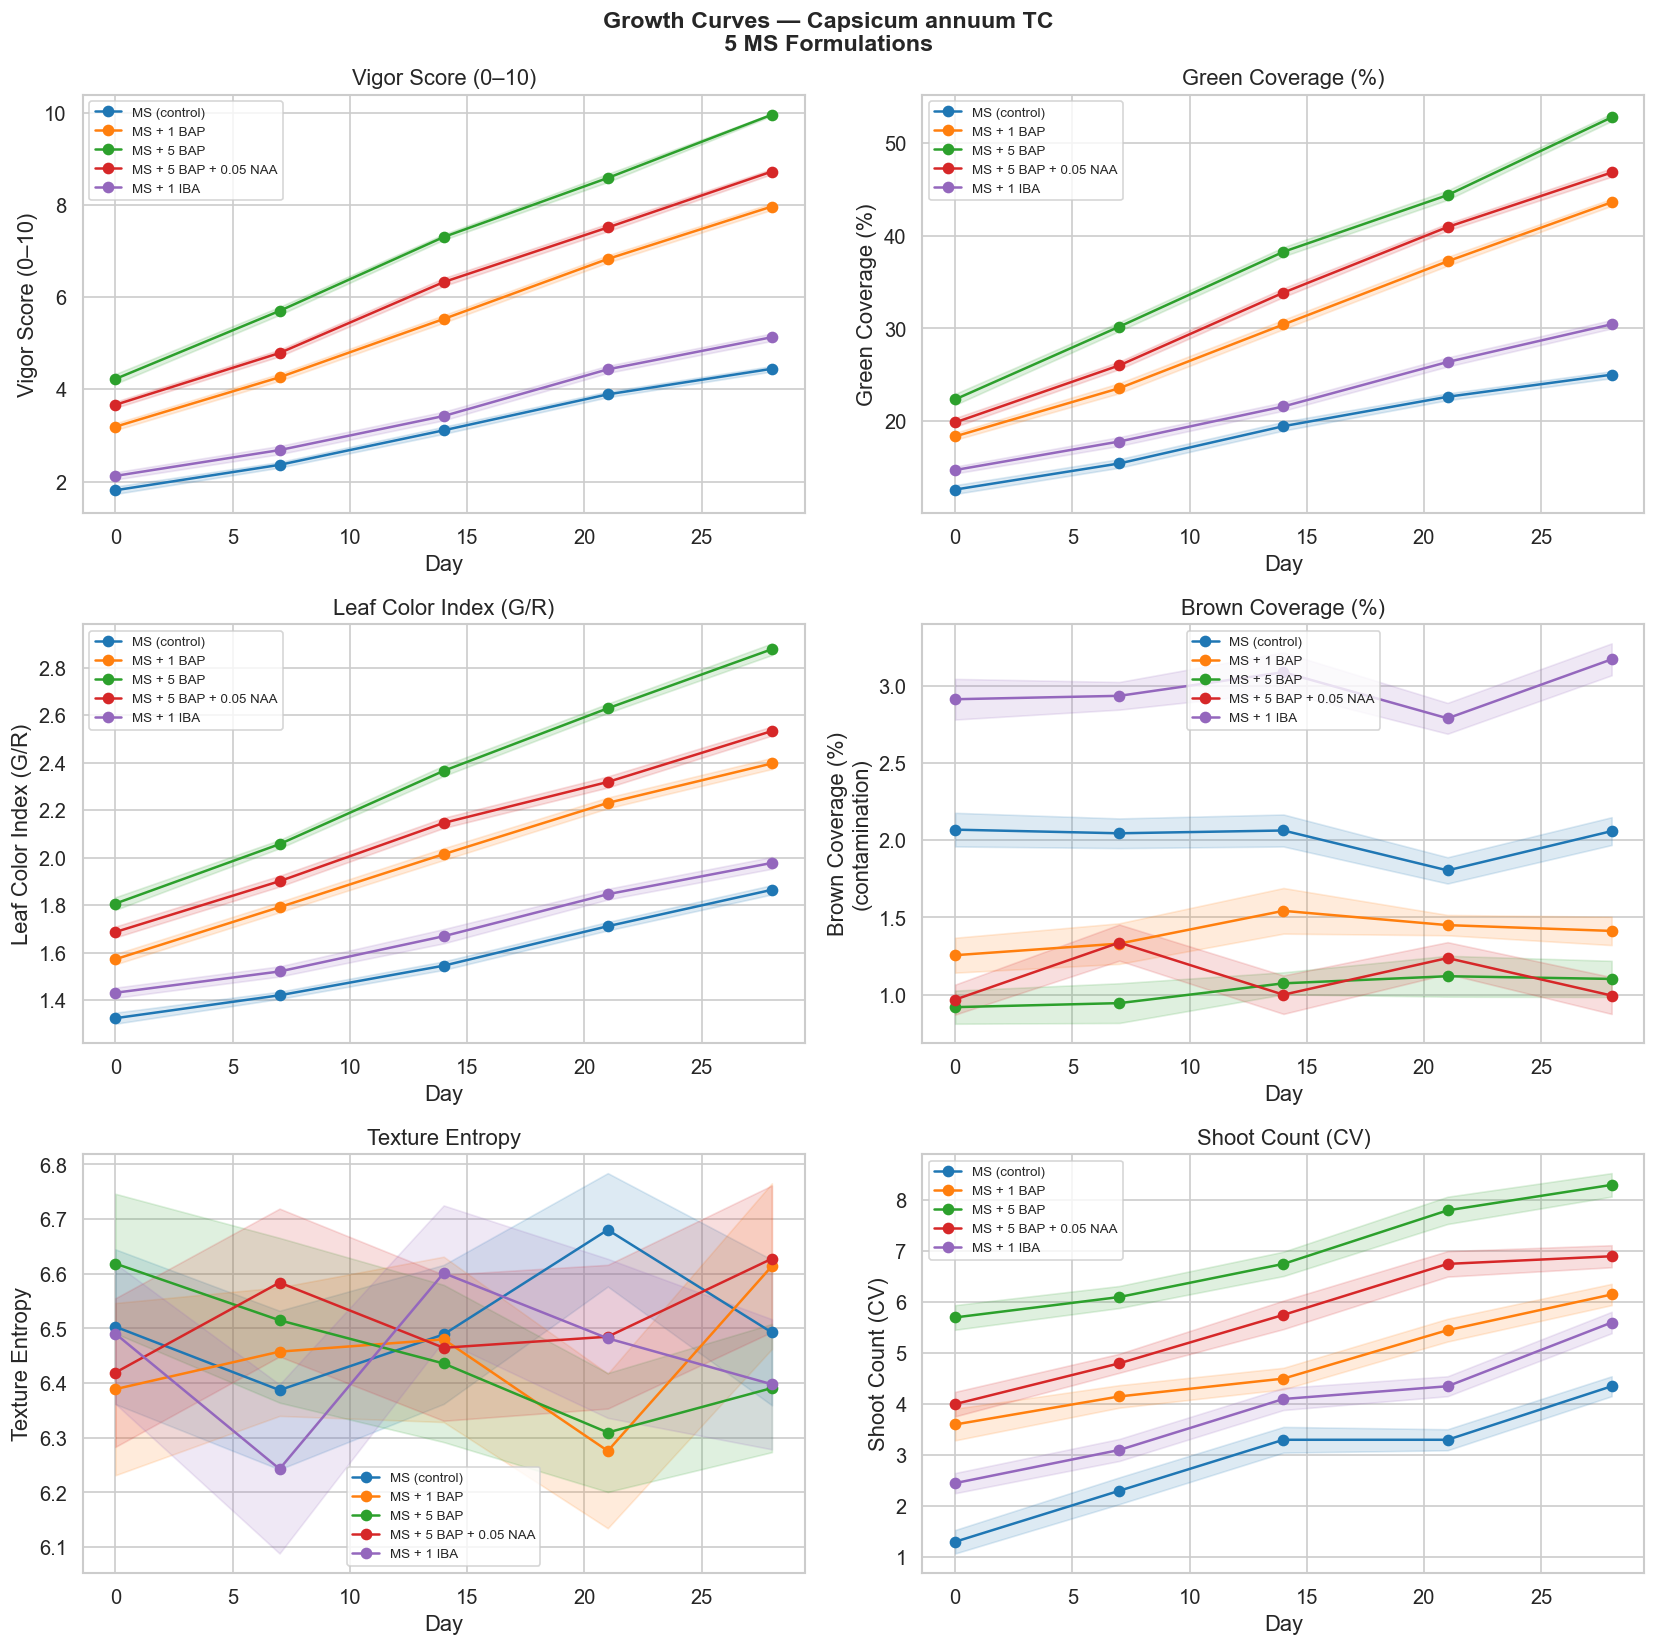

บันทึกแล้ว: results/growth_curves.png


In [5]:
METRICS = [
    ('vigor_score',        'Vigor Score (0–10)',       'tab:green'),
    ('green_coverage_pct', 'Green Coverage (%)',        'tab:olive'),
    ('leaf_color_index',   'Leaf Color Index (G/R)',    'tab:cyan'),
    ('brown_coverage_pct', 'Brown Coverage (%)\n(contamination)', 'tab:orange'),
    ('texture_entropy',    'Texture Entropy',           'tab:purple'),
    ('shoot_count_cv',     'Shoot Count (CV)',          'tab:blue'),
]

formula_order = ['A', 'B', 'C', 'D', 'E']
palette = sns.color_palette('tab10', n_colors=5)

if df.empty:
    print('ยังไม่มีข้อมูล — รอข้อมูลจากการสแกนขวด')
else:
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes = axes.flatten()

    for ax, (col, ylabel, _) in zip(axes, METRICS):
        grp = df.dropna(subset=[col]).groupby(['formula', 'day_point'])[col]
        mean_ = grp.mean().reset_index()
        se_   = grp.sem().reset_index().rename(columns={col: 'se'})
        agg   = mean_.merge(se_, on=['formula', 'day_point'])

        for i, f in enumerate(formula_order):
            sub = agg[agg.formula == f]
            if sub.empty:
                continue
            label = FORMULA_MAP.get(f, f)
            ax.plot(sub.day_point, sub[col], marker='o', label=label, color=palette[i])
            ax.fill_between(sub.day_point,
                            sub[col] - sub['se'],
                            sub[col] + sub['se'],
                            alpha=0.15, color=palette[i])

        ax.set_xlabel('Day')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel.split('\n')[0])
        ax.legend(fontsize=8, loc='best')

    fig.suptitle('Growth Curves — Capsicum annuum TC\n5 MS Formulations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/growth_curves.png', bbox_inches='tight')
    plt.show()
    print('บันทึกแล้ว: results/growth_curves.png')

## 3. Statistical Comparison — Kruskal-Wallis + Dunn's post-hoc
ใช้ Kruskal-Wallis (non-parametric) เพราะ sample size น้อย (20 ขวด/สูตร)

In [6]:
from itertools import combinations
from scipy.stats import kruskal

def kruskal_summary(data, metric, day_point=None):
    sub = data if day_point is None else data[data.day_point == day_point]
    groups = [sub[sub.formula == f][metric].dropna().values
              for f in formula_order if not sub[sub.formula == f][metric].dropna().empty]
    if len(groups) < 2:
        return None
    h, p = kruskal(*groups)
    day_label = f'Day {day_point}' if day_point else 'All days'
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    return {'metric': metric, 'day': day_label, 'H': round(h, 3), 'p': round(p, 4), 'sig': sig}

if df.empty:
    print('ยังไม่มีข้อมูล')
else:
    results = []
    last_day = df['day_point'].max()

    for col, label, _ in METRICS:
        r = kruskal_summary(df, col, last_day)
        if r:
            results.append(r)
        r = kruskal_summary(df, col)
        if r:
            results.append(r)

    if results:
        pd.DataFrame(results).style.map(
            lambda v: 'background-color: #d4edda' if v in ('*', '**', '***') else '',
            subset=['sig']
        )
    else:
        print('ข้อมูลน้อยเกินไปสำหรับ Kruskal-Wallis (ต้องการ ≥ 2 สูตรที่มีข้อมูล)')

In [7]:
from statsmodels.stats.multitest import multipletests

def pairwise_mwu(data, metric, day_point=None):
    sub = data if day_point is None else data[data.day_point == day_point]
    pairs = list(combinations(formula_order, 2))
    rows = []
    for f1, f2 in pairs:
        g1 = sub[sub.formula == f1][metric].dropna().values
        g2 = sub[sub.formula == f2][metric].dropna().values
        if len(g1) < 3 or len(g2) < 3:
            continue
        u, p = mannwhitneyu(g1, g2, alternative='two-sided')
        rows.append({'pair': f'{f1} vs {f2}', 'U': round(u, 1), 'p_raw': round(p, 4)})

    if not rows:
        return pd.DataFrame()
    res = pd.DataFrame(rows)
    _, p_adj, _, _ = multipletests(res['p_raw'], method='bonferroni')
    res['p_adj'] = p_adj.round(4)
    res['sig'] = res['p_adj'].apply(lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))
    return res

if df.empty:
    print('ยังไม่มีข้อมูล')
else:
    last_day = df['day_point'].max()
    print(f'=== Vigor Score @ Day {last_day} ===')
    result = pairwise_mwu(df, 'vigor_score', last_day)
    if result.empty:
        print('ข้อมูลน้อยเกินไป (ต้องการ ≥ 3 ตัวอย่างต่อสูตร)')
    else:
        display(result)

=== Vigor Score @ Day 28 ===


,pair,U,p_raw,p_adj,sig
0,A vs B,0.0,0.0,0.0,***
1,A vs C,0.0,0.0,0.0,***
2,A vs D,0.0,0.0,0.0,***
3,A vs E,29.5,0.0,0.0,***
4,B vs C,0.0,0.0,0.0,***
5,B vs D,11.0,0.0,0.0,***
6,B vs E,400.0,0.0,0.0,***
7,C vs D,400.0,0.0,0.0,***
8,C vs E,400.0,0.0,0.0,***
9,D vs E,400.0,0.0,0.0,***


## 4. Contamination Rate per Formulation

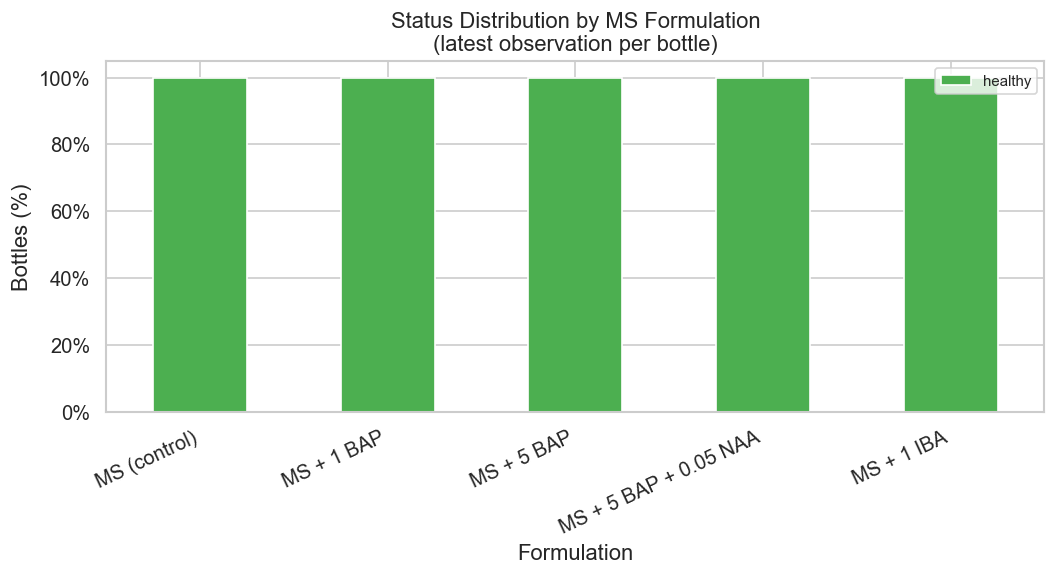

บันทึกแล้ว: results/contamination_rate.png


status,healthy
formula,
A,100.0
B,100.0
C,100.0
D,100.0
E,100.0


In [8]:
if df.empty:
    print('ยังไม่มีข้อมูล')
else:
    latest = df.sort_values('day_point').groupby('bottle_id').last().reset_index()

    cont_rate = (
        latest.groupby('formula')['status']
        .value_counts(normalize=True)
        .mul(100).round(1)
        .rename('pct')
        .reset_index()
    )

    pivot = cont_rate.pivot(index='formula', columns='status', values='pct').fillna(0)
    pivot = pivot.reindex(formula_order).reindex(
        columns=[c for c in ['healthy','contaminated','dead','unknown'] if c in pivot.columns]
    )
    pivot = pivot.dropna(how='all')

    if pivot.empty or pivot.select_dtypes('number').empty:
        print('ไม่มีข้อมูล status')
    else:
        color_map = {'healthy': '#4caf50', 'contaminated': '#f44336',
                     'dead': '#9e9e9e', 'unknown': '#ff9800'}
        colors = [color_map.get(c, '#cccccc') for c in pivot.columns]

        ax = pivot.plot(kind='bar', stacked=True, figsize=(9, 5), color=colors)
        ax.set_xlabel('Formulation')
        ax.set_ylabel('Bottles (%)')
        ax.set_title('Status Distribution by MS Formulation\n(latest observation per bottle)')
        ax.set_xticklabels([FORMULA_MAP.get(f, f) for f in pivot.index], rotation=25, ha='right')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend(loc='upper right', fontsize=9)
        plt.tight_layout()
        plt.savefig('../results/contamination_rate.png', bbox_inches='tight')
        plt.show()
        print('บันทึกแล้ว: results/contamination_rate.png')

    display(pivot)

## 5. Heatmap — Mean Vigor Score (Formulation × Day)

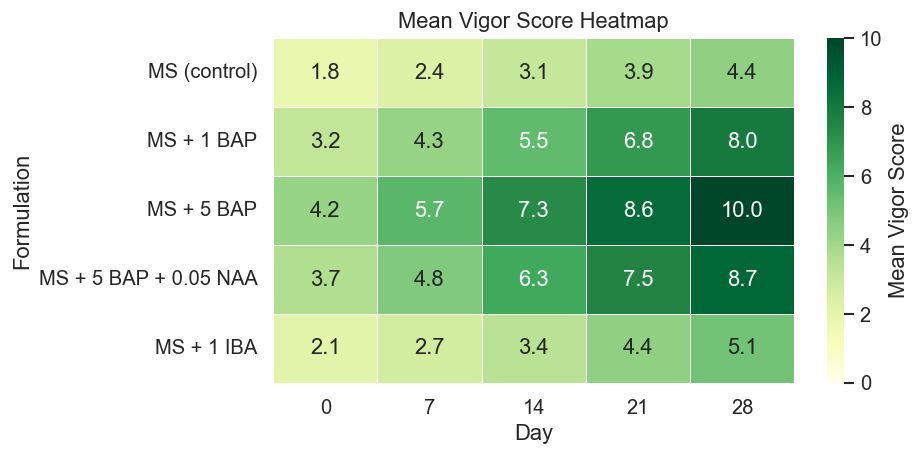

บันทึกแล้ว: results/vigor_heatmap.png


In [9]:
heat = df.dropna(subset=['vigor_score']).groupby(['formula', 'day_point'])['vigor_score'].mean().unstack()
heat = heat.reindex(formula_order)
heat.index = [FORMULA_MAP.get(f, f) for f in heat.index]

if not heat.empty:
    fig, ax = plt.subplots(figsize=(max(8, len(heat.columns) * 0.8), 4))
    sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlGn', linewidths=0.5,
                vmin=0, vmax=10, ax=ax,
                cbar_kws={'label': 'Mean Vigor Score'})
    ax.set_xlabel('Day')
    ax.set_ylabel('Formulation')
    ax.set_title('Mean Vigor Score Heatmap')
    plt.tight_layout()
    plt.savefig('../results/vigor_heatmap.png', bbox_inches='tight')
    plt.show()
    print('บันทึกแล้ว: results/vigor_heatmap.png')
else:
    print('ยังไม่มีข้อมูล vigor_score')

## 6. Scatter — Green Coverage vs Vigor Score (colored by formula)

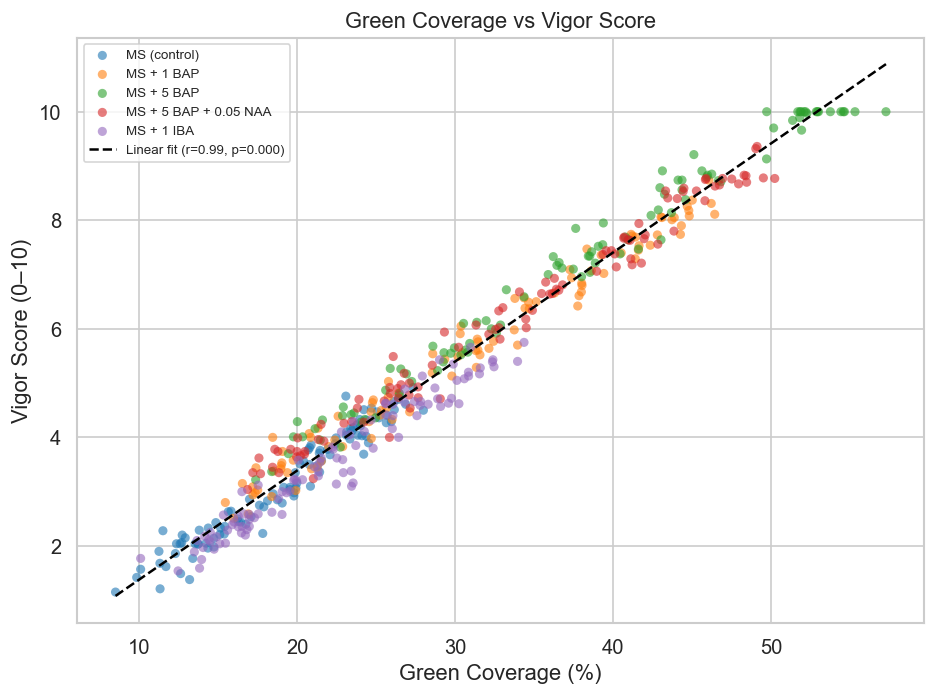

In [10]:
plot_df = df.dropna(subset=['green_coverage_pct', 'vigor_score'])

if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(8, 6))
    for i, f in enumerate(formula_order):
        sub = plot_df[plot_df.formula == f]
        ax.scatter(sub.green_coverage_pct, sub.vigor_score,
                   label=FORMULA_MAP.get(f, f), alpha=0.6, s=30,
                   color=palette[i], edgecolors='none')

    # regression line (all data)
    x = plot_df.green_coverage_pct.values
    y = plot_df.vigor_score.values
    m, b, r, p, _ = stats.linregress(x, y)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m * xr + b, 'k--', lw=1.5,
            label=f'Linear fit (r={r:.2f}, p={p:.3f})')

    ax.set_xlabel('Green Coverage (%)')
    ax.set_ylabel('Vigor Score (0–10)')
    ax.set_title('Green Coverage vs Vigor Score')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('../results/green_vs_vigor.png', bbox_inches='tight')
    plt.show()
else:
    print('ยังไม่มีข้อมูล')

## 7. Export summary CSV

In [11]:
summary = df.groupby(['formula', 'day_point']).agg(
    n=('bottle_id', 'count'),
    vigor_mean=('vigor_score', 'mean'),
    vigor_sd=('vigor_score', 'std'),
    green_mean=('green_coverage_pct', 'mean'),
    green_sd=('green_coverage_pct', 'std'),
    lci_mean=('leaf_color_index', 'mean'),
    brown_mean=('brown_coverage_pct', 'mean'),
    entropy_mean=('texture_entropy', 'mean'),
    shoot_mean=('shoot_count_cv', 'mean'),
).round(3).reset_index()
summary['formula_label'] = summary['formula'].map(FORMULA_MAP)

out_path = Path('../results/phenotype_summary.csv')
out_path.parent.mkdir(exist_ok=True)
summary.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'บันทึกแล้ว: {out_path}')
summary

บันทึกแล้ว: ..\results\phenotype_summary.csv


,formula,day_point,n,vigor_mean,vigor_sd,green_mean,green_sd,lci_mean,brown_mean,entropy_mean,shoot_mean,formula_label
0,A,0,20,1.812,0.363,12.623,2.138,1.325,2.068,6.503,1.30,MS (control)
1,A,7,20,2.363,0.273,15.440,2.094,1.421,2.045,6.387,2.30,MS (control)
2,A,14,20,3.112,0.349,19.460,2.130,1.546,2.062,6.489,3.30,MS (control)
3,A,21,20,3.891,0.279,22.630,1.648,1.712,1.805,6.680,3.30,MS (control)
4,A,28,20,4.445,0.264,25.014,1.713,1.865,2.058,6.493,4.35,MS (control)
5,B,0,20,3.190,0.337,18.360,1.705,1.573,1.256,6.389,3.60,MS + 1 BAP
6,B,7,20,4.262,0.347,23.557,2.444,1.792,1.331,6.458,4.15,MS + 1 BAP
7,B,14,20,5.524,0.368,30.429,2.288,2.015,1.543,6.480,4.50,MS + 1 BAP
8,B,21,20,6.826,0.359,37.245,2.165,2.231,1.451,6.276,5.45,MS + 1 BAP
9,B,28,20,7.962,0.325,43.612,1.704,2.397,1.413,6.614,6.15,MS + 1 BAP
